# 01 — Exploratory analysis

This project uses synthetic data inspired by common online gaming analytics use cases. It does not contain confidential or proprietary Junglee Games data.

Population: players with at least one game in the 30 days before each prediction date.
Label: no games in the following 30 days. Charts below use the June holdout unless noted.
Every rate is computed in this notebook from `data/processed/churn_dataset.csv`.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Project root:", ROOT)


Project root: /workspace/player-churn-prediction


In [2]:
from src.eda_report import build_eda
insights = build_eda()
holdout = pd.read_csv(ROOT / "data/processed/churn_dataset.csv")
holdout = holdout.loc[holdout["dataset_split"] == "test"].copy()
rate = float(holdout["churned"].mean())
display(Markdown(
    f"**June holdout:** {len(holdout):,} active players, churn rate **{rate:.1%}**. "
    "That is the share who played in the prior 30 days and then recorded no game "
    "in the next 30. CRM is not trying to 'predict the 78% who stay' — it is trying "
    "to find this minority before the month is over."
))


17:27:04 INFO matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


17:27:04 INFO matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


17:27:05 INFO matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


17:27:05 INFO matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


17:27:05 INFO src.eda_report - EDA written. June churn rate 0.216 on 71,164 players


**June holdout:** 71,164 active players, churn rate **21.6%**. That is the share who played in the prior 30 days and then recorded no game in the next 30. CRM is not trying to 'predict the 78% who stay' — it is trying to find this minority before the month is over.

In [3]:
def show_table(name, column, interpretation):
    table = pd.read_csv(ROOT / "reports/aggregates" / name)
    display(table)
    top = table.sort_values("churn_rate", ascending=False).iloc[0]
    bottom = table.sort_values("churn_rate", ascending=False).iloc[-1]
    display(Markdown(
        f"**{interpretation}** Highest: `{top[column]}` at {top['churn_rate']:.1%} "
        f"({int(top['players']):,} players). Lowest: `{bottom[column]}` at {bottom['churn_rate']:.1%} "
        f"({int(bottom['players']):,} players)."
    ))
    return table

show_table("by_vip.csv", "vip_segment", "VIP is a route and a value cut, not a single-cause explanation of lapse.")
show_table("by_channel.csv", "acquisition_channel", "Channel gaps that survive are about acquisition quality. They are usually smaller than recency gaps, which is what you want before you overfit media mix.")
show_table("by_device.csv", "device_type", "Device shifts engagement slightly. It should not be the story you take to CRM.")
show_table("by_game_type.csv", "preferred_game_type", "Preferred game is the product the journey should mention. A large churn gap here means the format, not just the player, is part of the lapse.")
show_table("by_tenure.csv", "tenure_bucket", "New accounts and veterans do not lapse for the same operational reason. Tenure buckets tell you whether the book is a welcome-journey problem or a save-the-regular problem.")


,vip_segment,players,churn_rate
0,Silver,7147,0.2615
1,Bronze,11111,0.2268
2,Regular,37272,0.2096
3,Platinum,5301,0.2075
4,Gold,8042,0.2068
5,Diamond,2291,0.1890


**VIP is a route and a value cut, not a single-cause explanation of lapse.** Highest: `Silver` at 26.2% (7,147 players). Lowest: `Diamond` at 18.9% (2,291 players).

,acquisition_channel,players,churn_rate
0,Affiliate,7212,0.2651
1,Organic,21347,0.2193
2,Google Ads,15459,0.2153
3,Influencer,5510,0.2129
4,Facebook,11468,0.2113
5,Referral,10168,0.1851


**Channel gaps that survive are about acquisition quality. They are usually smaller than recency gaps, which is what you want before you overfit media mix.** Highest: `Affiliate` at 26.5% (7,212 players). Lowest: `Referral` at 18.5% (10,168 players).

,device_type,players,churn_rate
0,iOS,15634,0.2191
1,Web,6962,0.2182
2,Android,48568,0.2152


...

,preferred_game_type,players,churn_rate
0,Deals Rummy,16379,0.2416
1,Pool Rummy,17146,0.2268
2,Tournaments,11175,0.2220
3,Points Rummy,26464,0.1917


**Preferred game is the product the journey should mention. A large churn gap here means the format, not just the player, is part of the lapse.** Highest: `Deals Rummy` at 24.2% (16,379 players). Lowest: `Points Rummy` at 19.2% (26,464 players).

,tenure_bucket,players,churn_rate
0,0-30,1731,0.2467
1,91-180,21443,0.2244
2,365+,2374,0.2203
3,31-90,14635,0.2172
4,181-365,30981,0.2085


**New accounts and veterans do not lapse for the same operational reason. Tenure buckets tell you whether the book is a welcome-journey problem or a save-the-regular problem.** Highest: `0-30` at 24.7% (1,731 players). Lowest: `181-365` at 20.8% (30,981 players).

,tenure_bucket,players,churn_rate
0,0-30,1731,0.2467
1,91-180,21443,0.2244
2,365+,2374,0.2203
3,31-90,14635,0.2172
4,181-365,30981,0.2085


In [4]:
show_table("by_games.csv", "games_bucket", "Players with very few games in the feature window are closer to an empty next month. High-volume players still churn — those are the shock cases a recency-only rule misses.")
show_table("by_deposit.csv", "deposit_bucket", "Funding and play move together, imperfectly. A funded player can still leave, and an unfunded grinder can stay.")
show_table("by_withdrawal.csv", "withdrawal_bucket", "Withdrawal amount is not a clean 'about to leave' flag on its own. Combined with high risk it becomes the win-back route, because some cash-outs are healthy.")
show_table("by_recency.csv", "recency_bucket", "Days since last game is the cleanest single cut in this book. The gradient from 'played yesterday' to 'played two weeks ago' is the practical version of the churn definition.")
show_table("by_sessions.csv", "session_bucket", "Session frequency tracks the habit. A player who still opens the app is a different save from one who has stopped logging in.")
show_table("by_activity_decline.csv", "activity_decline_flag", "The decline flag is a CRM key, not the whole model. Flagged players churn more; unflagged players still contain shock exits.")
show_table("by_value.csv", "value_bucket", "Lifetime rake quartiles show whether value and risk move together. High value is not automatically low risk — that is the VIP-at-risk book.")


,games_bucket,players,churn_rate
0,1-5,6203,0.3458
1,6-15,16893,0.3091
2,16-40,23920,0.2106
3,81+,5127,0.1713
4,41-80,19021,0.1113


**Players with very few games in the feature window are closer to an empty next month. High-volume players still churn — those are the shock cases a recency-only rule misses.** Highest: `1-5` at 34.6% (6,203 players). Lowest: `41-80` at 11.1% (19,021 players).

,deposit_bucket,players,churn_rate
0,NaN,27522,0.2783
1,1-100,371,0.2022
2,101-500,19086,0.1877
3,501-2000,15423,0.1724
4,2000+,8762,0.1625


**Funding and play move together, imperfectly. A funded player can still leave, and an unfunded grinder can stay.** Highest: `nan` at 27.8% (27,522 players). Lowest: `2000+` at 16.3% (8,762 players).

,withdrawal_bucket,players,churn_rate
0,1000+,13813,0.2208
1,NaN,56969,0.2153
2,101-1000,382,0.2120


...

,activity_decline_flag,players,churn_rate
0,1,24573,0.2477
1,0,46591,0.1999


**The decline flag is a CRM key, not the whole model. Flagged players churn more; unflagged players still contain shock exits.** Highest: `1.0` at 24.8% (24,573 players). Lowest: `0.0` at 20.0% (46,591 players).

,value_bucket,players,churn_rate
0,Q1 low rake,17791,0.2768
1,Q2,17791,0.2125
2,Q4 high rake,17791,0.2124
3,Q3,17791,0.1639


**Lifetime rake quartiles show whether value and risk move together. High value is not automatically low risk — that is the VIP-at-risk book.** Highest: `Q1 low rake` at 27.7% (17,791 players). Lowest: `Q3` at 16.4% (17,791 players).

,value_bucket,players,churn_rate
0,Q1 low rake,17791,0.2768
1,Q2,17791,0.2125
2,Q4 high rake,17791,0.2124
3,Q3,17791,0.1639


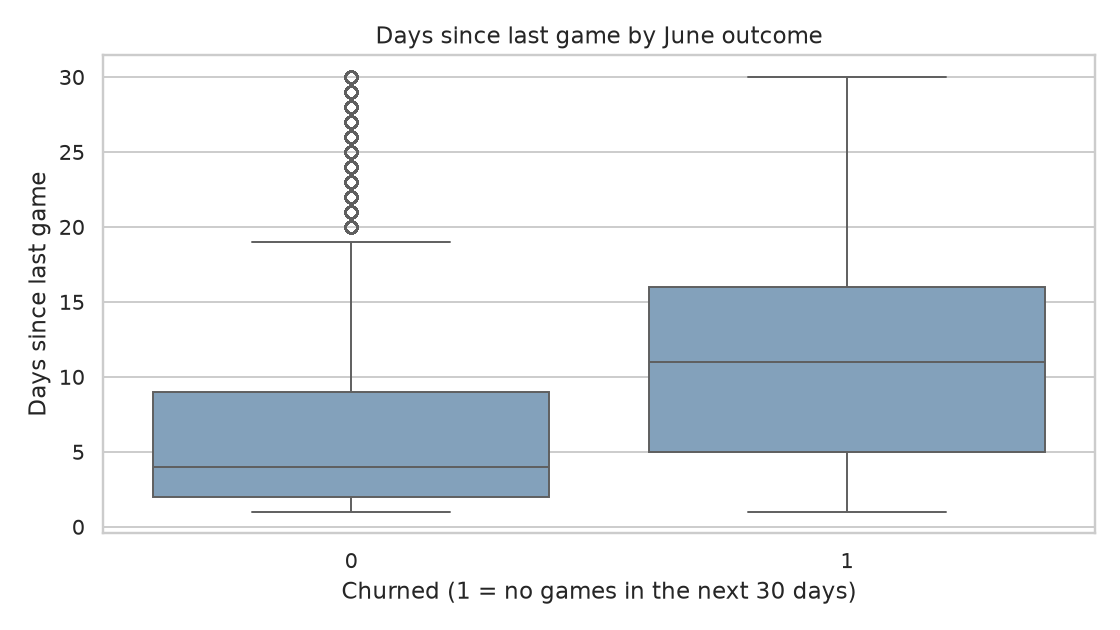

The churned group sits further from the last game. Overlap remains, so a hard recency rule still misses recent players who stop suddenly.

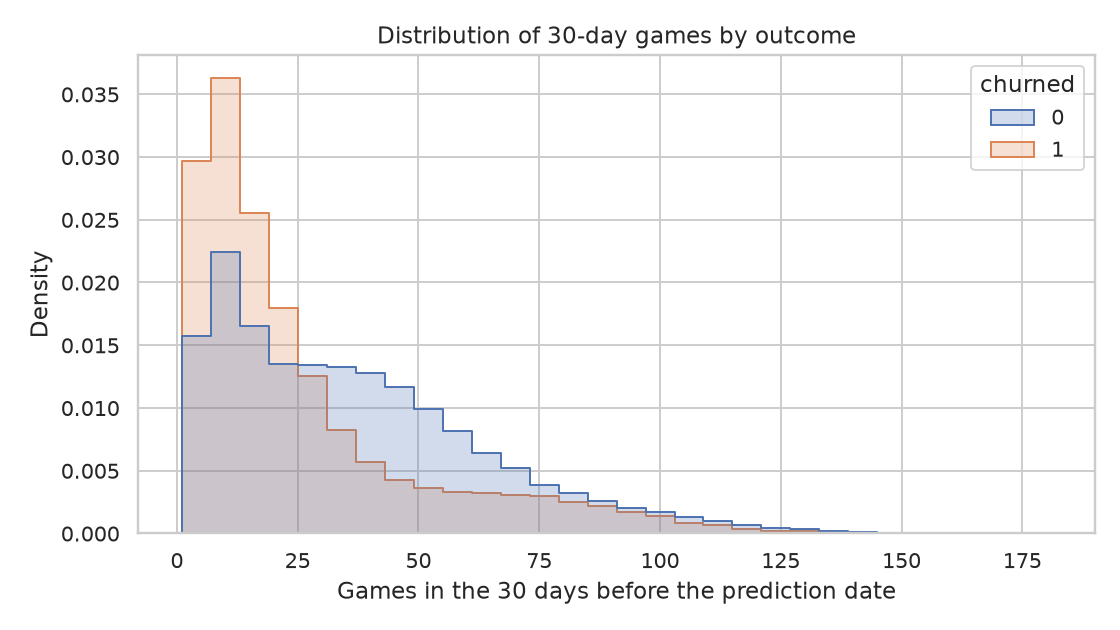

Churned players are shifted toward fewer games, with a long right tail. Volume alone will not separate the classes.

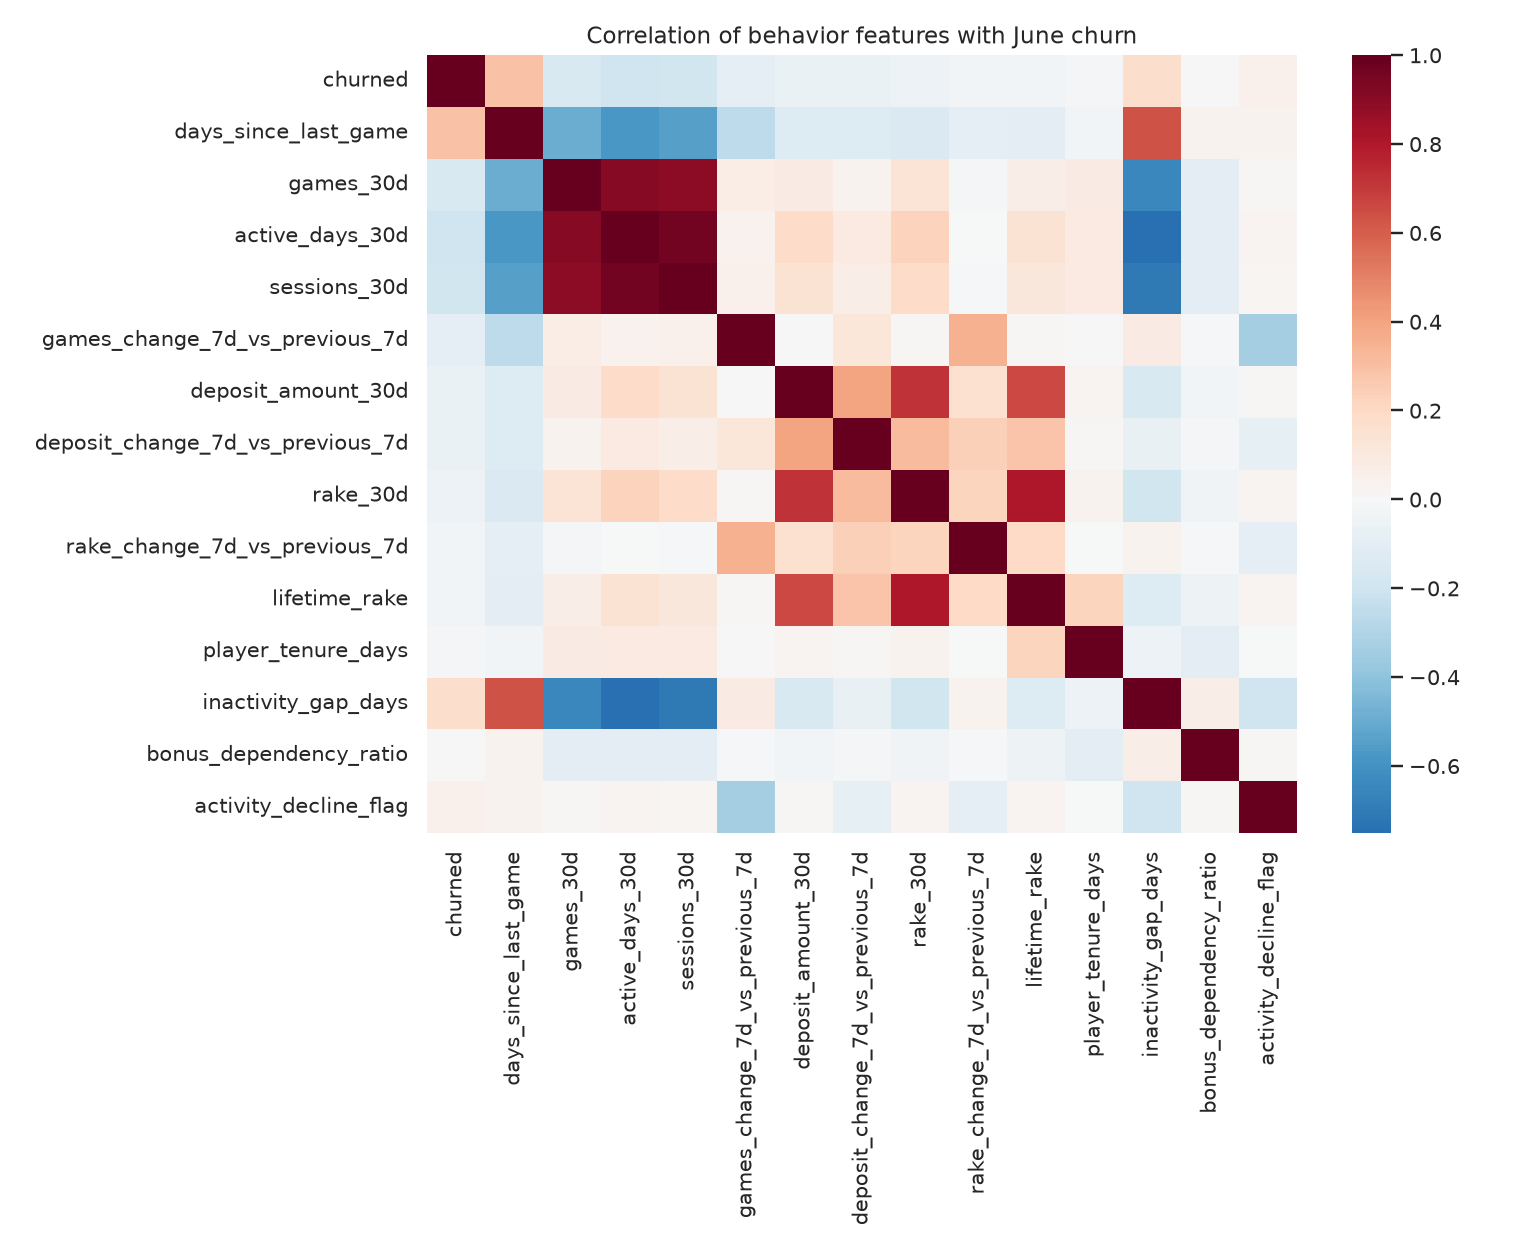

Correlations with churn are real and moderate. No single column is the label in disguise.

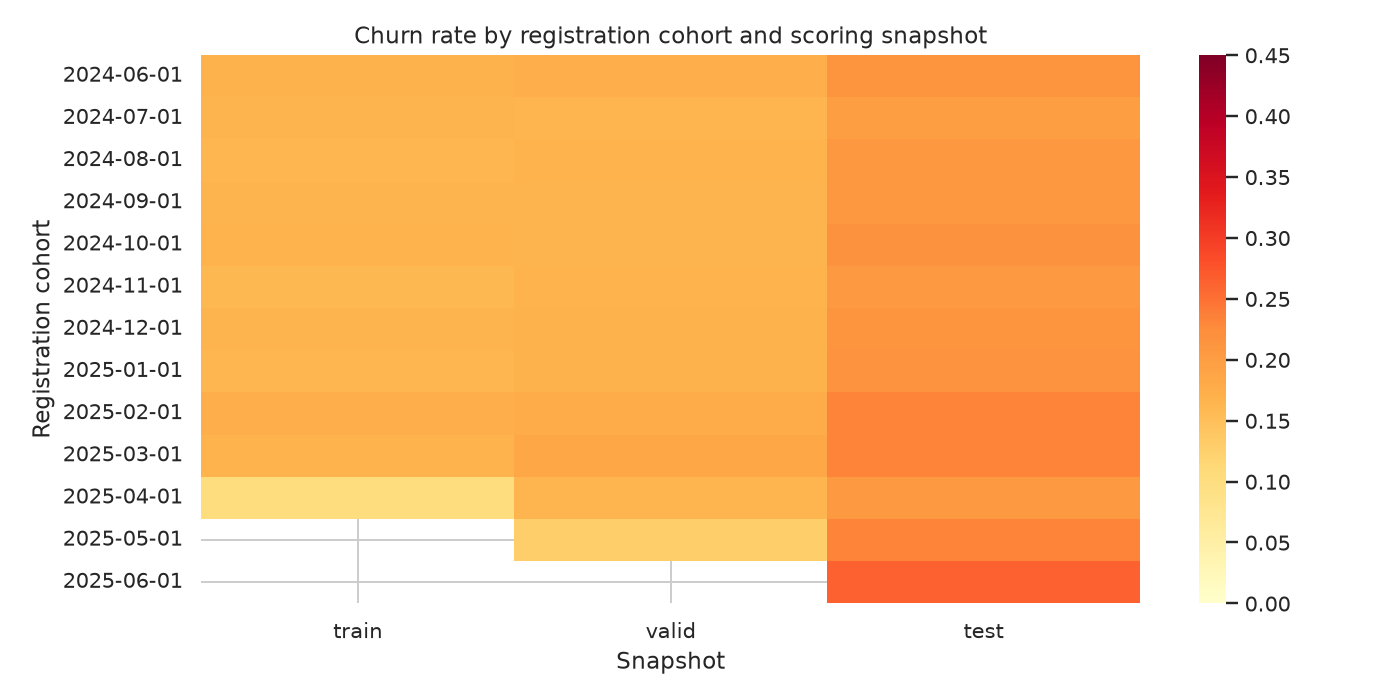

Registration cohort by snapshot is the acquisition view of the same definition. Read down a cohort to see whether a class got riskier as it aged, and across a snapshot to see the month.

,correlation_with_churn
active_days_30d,-0.1999
sessions_30d,-0.1956
games_30d,-0.1625
games_change_7d_vs_previous_7d,-0.0970
deposit_amount_30d,-0.0657
deposit_change_7d_vs_previous_7d,-0.0611
rake_30d,-0.0559
lifetime_rake,-0.0381
rake_change_7d_vs_previous_7d,-0.0381
player_tenure_days,-0.0138


Recency correlation with churn is 0.29. Games in 30 days: -0.16. Week-on-week games change: -0.10. Negative volume and negative week-on-week change both point at higher churn, which matches the operating story.

In [5]:
from IPython.display import Image
for figure, note in [
    ("recency_boxplot.png", "The churned group sits further from the last game. Overlap remains, so a hard recency rule still misses recent players who stop suddenly."),
    ("games_distribution_by_churn.png", "Churned players are shifted toward fewer games, with a long right tail. Volume alone will not separate the classes."),
    ("correlation_heatmap.png", "Correlations with churn are real and moderate. No single column is the label in disguise."),
    ("cohort_churn_heatmap.png", "Registration cohort by snapshot is the acquisition view of the same definition. Read down a cohort to see whether a class got riskier as it aged, and across a snapshot to see the month."),
]:
    display(Image(filename=str(ROOT / "reports/figures" / figure)))
    display(Markdown(note))

corr = pd.read_csv(ROOT / "reports/aggregates/correlation_matrix.csv", index_col=0)
display(corr["churned"].sort_values().to_frame("correlation_with_churn"))
display(Markdown(
    f"Recency correlation with churn is {insights['corr_days_since_last_game']:.2f}. "
    f"Games in 30 days: {insights['corr_games_30d']:.2f}. "
    f"Week-on-week games change: {insights['corr_games_change']:.2f}. "
    "Negative volume and negative week-on-week change both point at higher churn, which matches the operating story."
))
